In [33]:
# %pip install seaborn 
%pip install pyarrow
import polars as pl
import seaborn as sns 
import numpy as np 
import pandas as pd 
# mesmo n usando plt p gerar graficos, as figs podem ser mudadas vai plt
import matplotlib.pyplot as plt

   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/27.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/27.9 MB ? eta -:--:--
    --------------------------------------- 0.5/27.9 MB 714.0 kB/s eta 0:00:39
   - -------------------------------------- 0.8/27.9 MB 745.4 kB/s eta 0:00:37
   - -------------------------------------- 0.8/27.9 MB 745.4 kB/s eta 0:00:37
   - -------------------------------------- 1.0/27.9 MB 769.4 kB/s eta 0:00:35
   - -------------------------------------- 1.3/27.9 MB 789.0 kB/s eta 0:00:34
   - -------------------------------------- 1.3/27.9 MB 789.0 kB/s eta 0:00:34
   -- ------------------------------------- 1.6/27.9 MB 805.6 kB/s eta 0:00:33
   -- ------------------------------------- 1.8/27.9 MB 817.1 kB/s eta 0:00:32
   --- -----------

In [4]:
ARQUIVO = r'C:\analise de dados\arquivosBF\dados_bronze\df_bf.parquet'

In [5]:
df_bf = pl.read_parquet(ARQUIVO)

In [6]:
df_bf.glimpse()

Rows: 61405684
Columns: 9
$ MÊS COMPETÊNCIA        <i64> 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501
$ MÊS REFERÊNCIA         <i64> 202308, 202309, 202310, 202311, 202312, 202401, 202401, 202401, 202401, 202401
$ UF                     <str> 'SP', 'SP', 'SP', 'SP', 'SP', 'CE', 'PA', 'SP', 'SP', 'SP'
$ CÓDIGO MUNICÍPIO SIAFI <i64> 7071, 7071, 7071, 7071, 7071, 1389, 479, 6313, 6313, 6887
$ NOME MUNICÍPIO         <str> 'SANTOS', 'SANTOS', 'SANTOS', 'SANTOS', 'SANTOS', 'FORTALEZA', 'LIMOEIRO DO AJURU', 'CARAPICUIBA', 'CARAPICUIBA', 'PIRASSUNUNGA'
$ CPF FAVORECIDO         <str> '***.085.106-**', '***.085.106-**', '***.085.106-**', '***.085.106-**', '***.085.106-**', '***.854.493-**', '***.868.792-**', '***.972.798-**', '***.696.858-**', '***.295.298-**'
$ NIS FAVORECIDO         <i64> 20643890445, 20643890445, 20643890445, 20643890445, 20643890445, 13024055192, 16025132403, 13310239852, 20217442743, 16017425650
$ NOME FAVORECIDO        <str> 'FERNANDA RAMO

In [9]:
df_por_uf = (
    df_bf.group_by('UF').agg(pl.col('VALOR PARCELA').sum())
).sort(by='VALOR PARCELA', descending=True)
df_por_uf

UF,VALOR PARCELA
str,f64
"""BA""",4873812943.00
"""SP""",4832367370.00
"""PE""",3144489836.00
"""RJ""",3110091213.00
"""MG""",3066228734.00
…,…
"""TO""",318216159.00
"""AC""",283759378.00
"""RO""",269374412.00


In [8]:
pl.Config.set_fmt_float('full')
pl.Config.set_float_precision(2)

polars.config.Config

In [10]:
df_por_uf_media = df_bf.group_by('UF').agg(
    pl.col('VALOR PARCELA').mean()
).sort(by='VALOR PARCELA', descending=True)
df_por_uf_media

UF,VALOR PARCELA
str,f64
"""RR""",735.05
"""AM""",725.02
"""AC""",716.49
"""AP""",715.44
"""PA""",695.76
…,…
"""BA""",658.33
"""PR""",657.92
"""SP""",657.81


c:\analise de dados\virtual\Lib\site-packages\seaborn\_core\data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


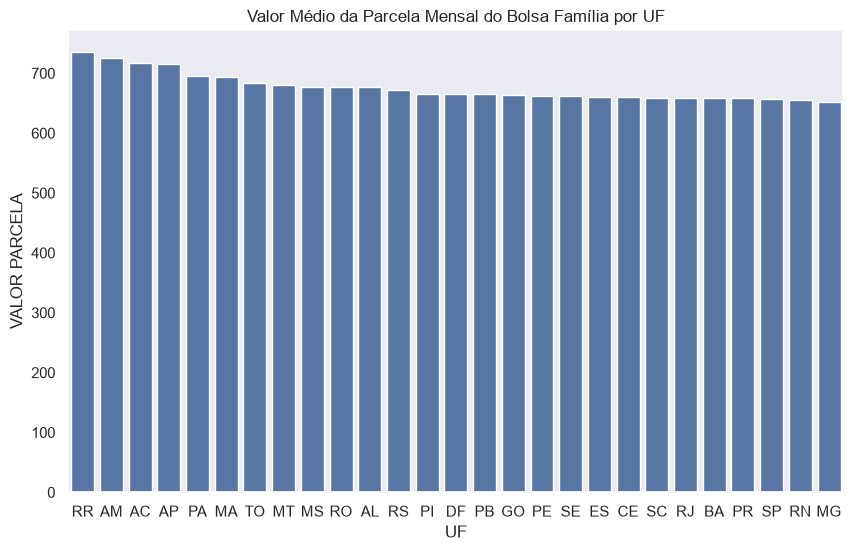

In [ ]:
# configurar tema do sns
sns.set_theme(style='dark'
              
              )
plt.figure(figsize=(10,6))
sns.barplot(df_por_uf_media,
             x='UF',
             y='VALOR PARCELA')
plt.title('Valor Médio da Parcela Mensal do Bolsa Família por UF')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_bf,
    x='CÓDIGO MUNICÍPIO SIAFI',
    y='VALOR PARCELA',
    palette='deep'
)